# **Laboratorio 3**

Integrantes del grupo
- Emmanuel Blanco - 202312743
- Juan David Guzmán - 202320890

In [1]:
# Importación de librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, validation_curve
from sklearn.utils import resample

## **Carga de datos**

In [2]:
training_data = pd.read_csv("./Datos_Laboratorio3.csv",sep=";")

print(f"Número de registros: {training_data.shape[0]}")
print(f"Número de variables: {training_data.shape[1]}")

training_data

Número de registros: 9698
Número de variables: 26


,Edad,Genero,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrici�n
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9693,73,Femenino,139.0,1.92,37.71,Ganancia muscular,Ninguno,Moderado,Avanzado,Pescetariano,...,0,0.0,0,0.0,0.34,89.5,7507,4.34,Alto,Balanceado
9694,30,Masculino,62.2,1.81,18.99,Ganancia muscular,Ninguno,Moderado,Intermedio,No-Vegetariano,...,1,13.5,0,0.0,0.15,75.4,3817,3.17,Bajo,Balanceado
9695,63,Masculino,50.5,1.79,15.76,Resistencia,PCOS,Bajo,Intermedio,No-Vegetariano,...,0,0.0,0,0.0,0.75,141.7,12949,3.33,Ninguno,Sin plan
9696,60,Otro,122.2,1.73,40.83,General,Ninguno,Alto,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.66,203.9,4772,2.64,Medio,Sin plan


## **Exploración de datos**

In [4]:
# Revisamos el tipo de dato de la variables

training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Genero                   9698 non-null   object 
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   object 
 6   Condicion_salud          9698 non-null   object 
 7   Nivel_Actividad          9698 non-null   object 
 8   Nivel_experiencia        9698 non-null   object 
 9   Dieta_preferida          9698 non-null   object 
 10  Horas_sue�o              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   object 
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia           

In [5]:
# Desplegamos la descripción de cada variable
training_data.describe()

,Edad,Peso,Altura,BMI,Horas_sue�o,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


Nos podemos percatar de que a Peso le faltan 11 valores y en Horas_sueño el máximo es 23 horas lo cual es muy probablemente un error. Es importante notar que Tiene_alergia, Problemas_digestivos, Fumador y Alcohol son variables binarias, por lo que es posible que requieran menos procesamiento

In [6]:
# Revisamos los datos nulos

porcentajes_NaN = (training_data.isnull().sum()/(training_data.shape[0]*100)).sort_values(ascending=False)
info_faltante = pd.DataFrame({
    'Columna':porcentajes_NaN.index,
    'Total de datos faltantes':training_data.isnull().sum()[porcentajes_NaN.index].values,
    '%':porcentajes_NaN.values
})
info_faltante[info_faltante['Total de datos faltantes']>0]

,Columna,Total de datos faltantes,%
0,Peso,11,0.000011


Como lo habiamos visto antes en el describe Peso es la única variable a la que habría que imputar valores para completarla

In [7]:
# Revisamos cuantos valores en Horas_sueño son mayores a 9.5 horas
training_data.loc[training_data.loc[:,"Horas_sue�o"]>9.5,["Horas_sue�o","Edad","Condicion_salud","Pasos_dia"]]

,Horas_sue�o,Edad,Condicion_salud,Pasos_dia
2250,23.0,46,Lesion,5212
7640,12.0,69,Ninguno,8801
9504,15.0,43,Ninguno,4510


La fila con id 2250 genera muchas dudas, pues las horas de sueño son excesivas para la edad de la persona, si bien está en condición de lesión, las horas de sueño no deberían ser superiores a las 15 horas como máximo. Y luego la columna Pasos_dia es completamente inconsistente con la condición de salud, pues tiene más pasos registrados que la persona del id 9504, y esto también es inconsistente con las horas de sueño (esta persona estaría dando 5212 en una hora cada día estando lesionado).

Las otras dos columnas tienen horas de sueño de 12 y 15, lo cuál también es un poco excesivo ya son cantidades mayores a medio día (implicaría que estas personas se la pasan durmiendo durante la mitad del día). Sin embargo, estos valores podrían tratarse como otuliers, ya que tampoco son desorbitantemente grandes como el de la fila 2250

In [8]:
# Habiendo establecido lo anterior, eliminiaremos la fila con id 2250, pues sus datos son incosistentes
training_data.drop(training_data[training_data["Horas_sue�o"] == 23].index, inplace=True)
training_data.loc[training_data.loc[:,"Horas_sue�o"]>9.5,["Horas_sue�o","Edad","Condicion_salud","Pasos_dia"]]

,Horas_sue�o,Edad,Condicion_salud,Pasos_dia
7640,12.0,69,Ninguno,8801
9504,15.0,43,Ninguno,4510


Revisamos los formatos de la variables categóricas

In [9]:
training_data["Genero"].value_counts()

Genero
Femenino     4718
Masculino    4611
Otro          368
Name: count, dtype: int64

In [10]:
training_data["Condicion_salud"].value_counts()

Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 763
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64

In [11]:
training_data["Entrenamiento_preferido"].value_counts()

Entrenamiento_preferido
Funcional       1666
Hit             1620
Flexibilidad    1618
Cardio          1602
Fuerza          1600
Balance         1591
Name: count, dtype: int64

In [12]:
training_data["Objetivo"].value_counts()

Objetivo
Ganancia muscular    2756
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

En objetivo es probable que grasa y Perdida grasa sean un mismo objetivo pero representado de manera distinta, tendremos que unificar este formato

In [13]:
training_data["Nivel_Actividad"].value_counts()

Nivel_Actividad
Moderado    3594
Bajo        3325
Alto        2778
Name: count, dtype: int64

In [14]:
training_data["Nivel_experiencia"].value_counts()

Nivel_experiencia
Intermedio      4099
Principiante    3608
Avanzado        1990
Name: count, dtype: int64

In [15]:
training_data["Dieta_preferida"].value_counts()

Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Vegetariano       2402
Pescetariano      2402
Animal              11
Name: count, dtype: int64

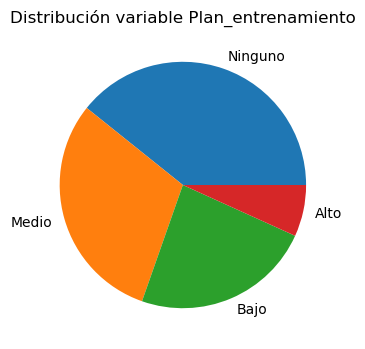

In [16]:
# Revisamos la variable objetivo Plan_entrenamiento
var1_count= training_data["Plan_entrenamiento"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(var1_count,labels=var1_count.index)
plt.title("Distribución variable Plan_entrenamiento")
plt.show()


Nuestra tarea respecto al problema es mejorar la recomendación de planes de entrenamiento, en este caso vemos que hay 4 categorías de recomendación, donde la categoría de recomendación más común en los datos de ninguno.

Teniendo estos datos en cuenta, podríamos tomar dos alternativas para manejar esta categorías más fácilmente:
1. Podríamos unificar las categorias Bajo, Medio y Alto, como categorías que indican la recomendación de un plan de entrenamiento. De esta manera nuestro modelo ya solo tendrá que clasificar los datos frente a si recomendar o no un plan de entrenamiento
2. Se podrían unificar las categorías Bajo y Ninguno, y Medio y Alto, de esta manera el modelo haría una calsificación entre la recomendación de un plan que no cambia mucho la rutina de una persona o de un plan que cambia significativamente la rutina de una persona

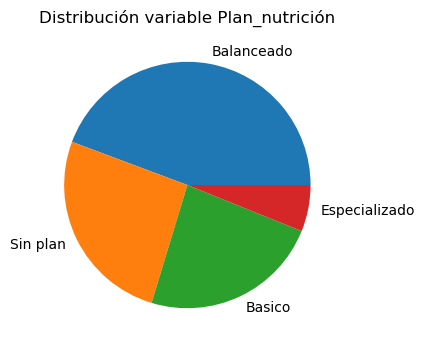

In [17]:
# Revisamos la variable objetivo Plan_nutrición

var2_count = training_data["Plan_nutrici�n"].value_counts()
plt.figure(figsize=(6,4))
plt.pie(var2_count,labels=var2_count.index)
plt.title("Distribución variable Plan_nutrición")
plt.show()

Respecto a esta segunda variable objetivo, podemos ver una situación bastante similar a la de la variable Plan_entrenamiento. Por lo tanto podemos proponer dos alternativas similares a las que se propusieron con respecto a la variable anteiror:
1. Unificar la categorías Basico, Balanceado y Especializado para que el modelo clasifique entre otorgar un plan de nutrición o no otorgarlo
2. Unificar las categorías Sin plan y Basico, y Balanceado y Especializado para clasificar entre si recomendar un plan sencillo (sin cambios o cambios básicos) o recomendar un plan más complejo (alimentación balanceada y especializada)

In [18]:
# Verificar registros duplicados
duplicados = training_data.duplicated().sum()
print(f"Número de registros duplicados:", duplicados)

Número de registros duplicados: 0


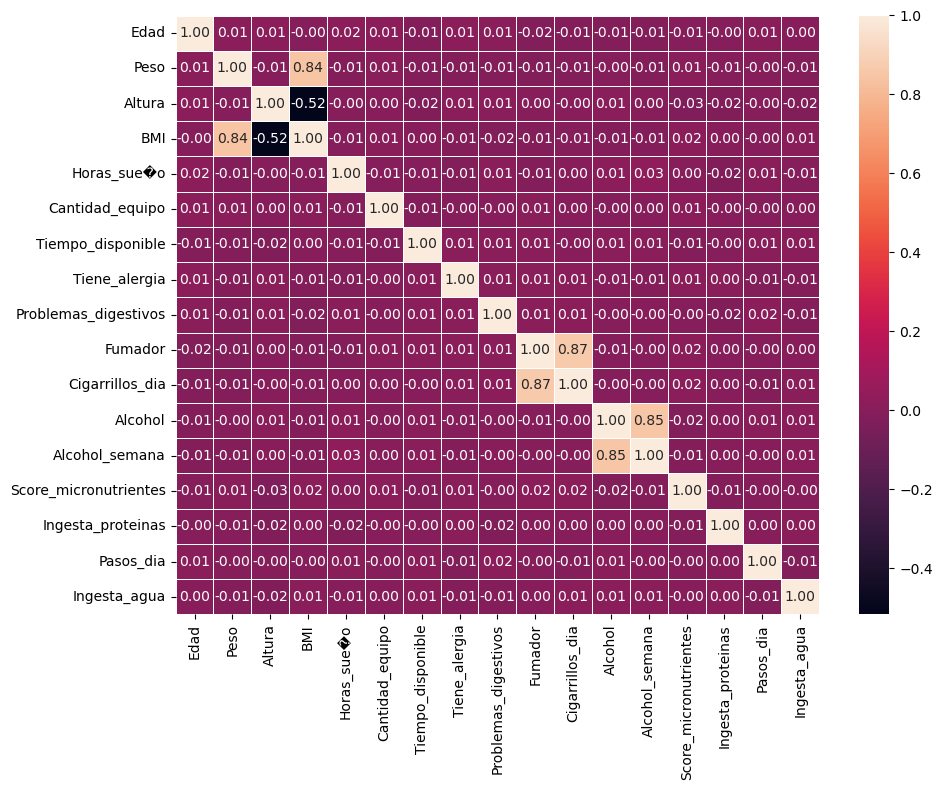

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(training_data.corr(numeric_only=True), annot=True, fmt=".2f", annot_kws={"size": 10},linewidths=0.5)
plt.tight_layout()
plt.show()

En el heatmap podemos ver que el índice de masa corporal tiene una correlación fuerte con la altura y el peso, por lo que lo mejor sería eliminar las variables altura y peso para la construcción de los modelos ya que están representadas a través de IMC (BMI).

Luego podemos ver que las variables Fumador y Cigarrillos_dia, y Alcohol y Alcohol_semana están fuertemente correlacionadas, esto se debe a que si en la columna Fumador/Alcohol hay un 0 en Cigarrillos_dia/Alcohol_semana habrá un cero (los que no son fumadores o consumen alcohol deberían tener un consumo de cero cigarrillos y alcohol al día), de contrario, si en la columna Fumador/Alcohol hay un 1, en Cigarrillos_dia/Alcohol_semana habrá un valor mayor a cero. Dicho esto, aún podemos distinguir entre consumidores de alcohol y tabaco sin las variables Fumador y Alcohol, por lo que estas variables deberían ser eliminadas.

## **Limpieza y preparación de datos**

En esta sección realizaremos los siguientes ajustes en los datos:
1. Unificar el formato Perdida de Grasa, grasa en la variable *Objetivo*
2. Preparar los datos para cada modelo a realizar:

   Para el modelo de clasificación con la variable Plan_entrenamiento:
   1. Unificar la categorias Alto, Medio y Bajo para hacer la clasificación entre recomendar un plan o no recomendar ninguno
   2. Separar datos para entrenamiento y test

   Para el modelo de clasificación con la variable Plan_nutrición:
   1. Unificar las categorías Sin plan y Basico, y Balanceado y Especializado para clasificar entre si recomendar un plan sencillo (sin cambios o cambios básicos) o recomendar un plan más complejo (alimentación balanceada y especializada)
   2. Separar datos para entrenamiento y test

In [20]:
# Primero realizamos los ajuste en la variable Objetivo

training_data.loc[training_data["Objetivo"] == "grasa", "Objetivo"] = "Perdida grasa"
training_data["Objetivo"].value_counts()

Objetivo
Ganancia muscular    2756
Perdida grasa        2598
General              2220
Resistencia          2123
Name: count, dtype: int64

In [21]:
# Hacemos dos copias de los datos con el pre-procesamiento realizado hasta este momento
data_plan_entrena = training_data.copy()
data_plan_nutri = training_data.copy()

### Preparación de datos para el modelos que usan la variable Plan_entrenamiento

In [22]:
# Unificamos las categorías Bajo, Medio, Alto de Plan_entrenamiento
data_plan_entrena["Recomendar_plan"] = np.where(data_plan_entrena["Plan_entrenamiento"].isin(["Bajo","Medio","Alto"]),1,0)
data_plan_entrena.loc[:,["Plan_entrenamiento","Recomendar_plan"]]

,Plan_entrenamiento,Recomendar_plan
0,Medio,1
1,Ninguno,0
2,Bajo,1
3,Ninguno,0
4,Medio,1
...,...,...
9693,Alto,1
9694,Bajo,1
9695,Ninguno,0
9696,Medio,1


In [23]:
# Separamos los datos en conjuntos de entrenamiento y de prueba
x_plan_entrena = data_plan_entrena.drop(columns=["Recomendar_plan"])
y_plan_entrena = data_plan_entrena["Recomendar_plan"]


#Revisar si se necesita stratify
x_train_plan_entrena, x_test_plan_entrena, y_train_plan_entrena, y_test_plan_entrena = train_test_split(x_plan_entrena, y_plan_entrena, test_size=0.2, random_state=1)
print("Set de datos de entrenamiento:")
print("Tamaño variables x_train: ",x_train_plan_entrena.shape)
print("Tamaño variables y_train: ",y_train_plan_entrena.shape)

print("\nSet de datos de prueba:")
print("Tamaño variables x_test: ",x_test_plan_entrena.shape)
print("Tamaño variables y_test: ",y_test_plan_entrena.shape)

Set de datos de entrenamiento:
Tamaño variables x_train:  (7757, 26)
Tamaño variables y_train:  (7757,)

Set de datos de prueba:
Tamaño variables x_test:  (1940, 26)
Tamaño variables y_test:  (1940,)


### Preparación de datos para modelos que usen la variable Plan_nutrición

In [24]:
# Unificamos las categorías Sin plan y Basico, y Balanceado y Especializado
data_plan_nutri["Tipo_nutricion"] = np.where(data_plan_nutri["Plan_nutrici�n"].isin(["Sin plan","Basico"]),1,0)
data_plan_nutri.loc[:,["Plan_nutrici�n","Tipo_nutricion"]]

,Plan_nutrici�n,Tipo_nutricion
0,Sin plan,1
1,Sin plan,1
2,Basico,1
3,Sin plan,1
4,Sin plan,1
...,...,...
9693,Balanceado,0
9694,Balanceado,0
9695,Sin plan,1
9696,Sin plan,1


In [25]:
# Separamos los datos en conjuntos de entrenamiento y de prueba
x_plan_nutri = data_plan_nutri.drop(columns=["Tipo_nutricion"])
y_plan_nutri = data_plan_nutri["Tipo_nutricion"]

# revisar si es necesario stratify
x_train_plan_nutri, x_test_plan_nutri, y_train_plan_nutri, y_test_plan_nutri = train_test_split(x_plan_nutri, y_plan_nutri, test_size=0.2, random_state=1)
print("Set de datos de entrenamiento:")
print("Tamaño variables x_train: ",x_train_plan_nutri.shape)
print("Tamaño variables y_train: ",y_train_plan_nutri.shape)

print("\nSet de datos de prueba:")
print("Tamaño variables x_test: ",x_test_plan_nutri.shape)
print("Tamaño variables y_test: ",y_test_plan_nutri.shape)

Set de datos de entrenamiento:
Tamaño variables x_train:  (7757, 26)
Tamaño variables y_train:  (7757,)

Set de datos de prueba:
Tamaño variables x_test:  (1940, 26)
Tamaño variables y_test:  (1940,)


## **Modelos de regresión logística**

### Modelo para clasificación con la variable Recomendar_plan (que surgió de la agrupación de la variable Plan_entrenamiento)

En este caso eliminamos Plan_nutrición porque es otra de las variables objetivo que queremosn usar en otro modelo y que no consideraremos para la clasificación con la variable Recomendar plan.

Por otro lado, Recomedar_plan es una agrupación de la categorías de la variable Plan_entrenamiento, por lo que debemos eliminar la variable original ya que ya está representada por la nueva variable binaria Recomendar_plan

Para ambas variables objetivos eliminaremos la variables Peso, Altura, Fumador y Alcohol por los motivos descritos en la exploración de datos

In [26]:
# Primero debemos eliminar las variables que no van a ser de utilidad en la creación del modelo
cols_to_drop = ["Peso","Altura","Alcohol","Fumador","Plan_nutrici�n","Plan_entrenamiento"]

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

In [27]:
# Identificaremos que columnas de nuestro dataframe son númericas y cuales son categóricas para poderles dar un distinto procesamiento en el Pipeline
cols_a_omitir = cols_to_drop = ["Peso","Altura","Alcohol","Fumador","Plan_nutrici�n","Plan_entrenamiento","Recomendar_plan"]

numeric_cols_plan_entrena = [
    col for col in data_plan_entrena.select_dtypes(include=[np.number]).columns
    if col not in cols_to_drop
]

categorical_cols_plan_entrena = [
    col for col in data_plan_entrena.select_dtypes(exclude=[np.number]).columns
    if col not in cols_to_drop
]

print("Columnas numéricas: ",numeric_cols_plan_entrena)
print("Columnas categóricas: ", categorical_cols_plan_entrena)

Columnas numéricas:  ['Edad', 'BMI', 'Horas_sue�o', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
Columnas categóricas:  ['Genero', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']


Dado que se encontraron algunos outliers en algunas de las columnas numéricas lo mejor es utilizar un RobustScaler para escalar este tipo de variables

In [28]:
numeric_transformer = RobustScaler()

Para las columnas categóricas usaremos OneHot Enconding

In [29]:
categorica_transformer = OneHotEncoder(handle_unknown='ignore', drop='if_binary')

Unimos estos transformadores en un columnTransformer que ayude a realizar las modificaciones a las columnas según su tipo

In [30]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols_plan_entrena),
        ('cat', categorica_transformer, categorical_cols_plan_entrena)
        ]
    )

Ahora pasamos a definir el pipeline para la regresión logística

In [31]:
pipeline_rl_plan_entrena = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(
        max_iter=1000,
     ))
])

Ahora utilizaremos GridSearchCV para encontrar los mejores parámetros para nuestro modelo

In [32]:
# El param_grid le pasará a gridSearch las combinaciones de hiperparámetros válidas
param_grid_rl = [
    # Combinaciones válidas con L2
    {
        'modelo__penalty': ['l2'],
        'modelo__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1]
    },
    # Combinaciones válidas con L1
    {
        'modelo__penalty': ['l1'],
        'modelo__solver': ['liblinear'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1]
    }
]

# Utilizamos KFold para la validación cruzada
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

grid_rl_plan_entrena = GridSearchCV(estimator=pipeline_rl_plan_entrena, param_grid=param_grid_rl, cv=kfold, scoring='f1', n_jobs=-1)

In [33]:
# Entrenamos al modelo con los datos de entrenamiento
grid_rl_plan_entrena.fit(x_train_plan_entrena, y_train_plan_entrena)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('dropper',
                                        FunctionTransformer(func=<function drop_columns at 0x000002013F13D940>)),
                                       ('preprocesador',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Edad',
                                                                          'BMI',
                                                                          'Horas_sue�o',
                                                                          'Cantidad_equipo',
                                                                          'Tiempo_disponible',
                                                                          'Tiene_alergia',
                                                                          'Problemas_digestivos',
                                                                          'Cig...
                                                                          'Nivel_experiencia',
                                                                          'Dieta_preferida',
                                                                          'Entrenamiento_preferido'])])),
                                       ('modelo',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid=[{'modelo__C': [0.1, 0.2, 0.5, 0.8, 1],
                          'modelo__penalty': ['l2'],
                          'modelo__solver': ['newton-cg', 'lbfgs',
                                             'liblinear']},
                         {'modelo__C': [0.1, 0.2, 0.5, 0.8, 1],
                          'modelo__penalty': ['l1'],
                          'modelo__solver': ['liblinear']}],
             scoring='f1')

Obtenemos los mejores parámetros obtenidos por GridSearch

In [34]:
print("Mejores hiperparámetros:", grid_rl_plan_entrena.best_params_)
print("Mejor puntaje medio en CV (f1):", grid_rl_plan_entrena.best_score_)
print("\n")
resultados = pd.DataFrame(grid_rl_plan_entrena.cv_results_)
cols = [
    'param_modelo__C',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = resultados[cols].sort_values(by='rank_test_score')
print(summary)

Mejores hiperparámetros: {'modelo__C': 0.2, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
Mejor puntaje medio en CV (f1): 0.9615012241065667


    param_modelo__C  mean_test_score  std_test_score  rank_test_score
5               0.2         0.961501        0.005985                1
3               0.2         0.961495        0.006372                2
4               0.2         0.961274        0.005821                3
2               0.1         0.961111        0.005219                4
0               0.1         0.960948        0.006156                5
1               0.1         0.960836        0.006140                6
7               0.5         0.960765        0.005813                7
8               0.5         0.960757        0.005598                8
6               0.5         0.960663        0.005898                9
17              0.5         0.960613        0.005446               10
19              1.0         0.960605        0.005547               11
18     

Podemos observar que el mejor modelo usa una penalización L2 con solver liblinear y un $c= 0.2$ que nos indica que se le otorga una buena importancia a la regularización

In [35]:
# Guardamos el mejor modelo
best_rl_model_plan_entrena = grid_rl_plan_entrena.best_estimator_

Ahora usamos el modelo para predecir las categorías sobre los datos de prueba

In [37]:
y_pred_plan_entrena = best_rl_model_plan_entrena.predict(x_test_plan_entrena)

# Y con la predicción hecha revisamos el reporte de clasificación
print(classification_report(y_test_plan_entrena,y_pred_plan_entrena,target_names=["No asignar plan","Asignar plan"]))

                 precision    recall  f1-score   support

No asignar plan       0.94      0.93      0.94       778
   Asignar plan       0.96      0.96      0.96      1162

       accuracy                           0.95      1940
      macro avg       0.95      0.95      0.95      1940
   weighted avg       0.95      0.95      0.95      1940



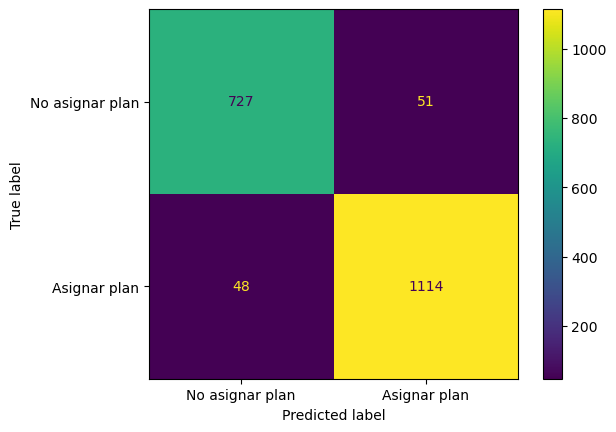

In [38]:
# También revisamos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test_plan_entrena, y_pred_plan_entrena, display_labels=["No asignar plan","Asignar plan"])
plt.show()

Y revisamos los coeficientes resultantes de este modelo

In [ ]:
preprocesador_fit = best_rl_model_plan_entrena.named_steps['preprocesador']
log_reg_fit = best_rl_model_plan_entrena.named_steps['modelo']

feature_names_num = preprocesador_fit.transformers_[0][2]
ohe = preprocesador_fit.transformers_[1][1]
feature_names_cat = ohe.get_feature_names_out(preprocesador_fit.transformers_[1][2])
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

coefs = log_reg_fit.coef_[0]
coef_df = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})

coef_df = coef_df.sort_values('coef', ascending=False)
coef_df.head(30)

,feature,coef
27,Nivel_Actividad_Alto,5.889076
30,Nivel_experiencia_Avanzado,5.649159
16,Objetivo_Ganancia muscular,3.149955
4,Tiempo_disponible,2.966333
1,BMI,2.412662
13,Genero_Femenino,0.569819
14,Genero_Masculino,0.510455
34,Dieta_preferida_No-Vegetariano,0.396239
36,Dieta_preferida_Vegano,0.309332
23,Condicion_salud_Hipertension,0.301488


### Modelo para clasificación con la variable Tipo_plan (que surgió de la agrupación de la variable Plan_nutrición)

En este caso eliminamos Plan_entrenamiento porque es otra de las variables objetivo que queremos usar en otro modelo y que no consideraremos para la clasificación con la variable Recomendar plan.

Por otro lado, Tipo_plan es una agrupación de la categorías de la variable Plan_nutrición, por lo que debemos eliminar la variable original ya que ya está representada por la nueva variable binaria Tipo_plan

Para ambas variables objetivo eliminaremos la variables Peso, Altura, Fumador y Alcohol por los motivos descritos en la exploración de datos

En este caso el dropper que definimos antes nos funciona también para este modelo

In [41]:
# Identificaremos que columnas de nuestro dataframe son númericas y cuales son categóricas para poderles dar un distinto procesamiento en el Pipeline
cols_a_omitir = cols_to_drop = ["Peso","Altura","Alcohol","Fumador","Plan_nutrici�n","Plan_entrenamiento","Tipo_nutricion"]

numeric_cols_plan_nutri = [
    col for col in data_plan_nutri.select_dtypes(include=[np.number]).columns
    if col not in cols_to_drop
]

categorical_cols_plan_nutri = [
    col for col in data_plan_nutri.select_dtypes(exclude=[np.number]).columns
    if col not in cols_to_drop
]

print("Columnas numéricas: ",numeric_cols_plan_nutri)
print("Columnas categóricas: ", categorical_cols_plan_nutri)

Columnas numéricas:  ['Edad', 'BMI', 'Horas_sue�o', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
Columnas categóricas:  ['Genero', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']


En este modelo podemos aplicar las mismas transformaciones que las que usamos para la regresión con la variable Plan_entrenamiento en el preprocesador

In [42]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols_plan_nutri),
        ('cat', categorica_transformer, categorical_cols_plan_nutri)
        ]
    )

# Ahora podemos construir el Pipeline
pipeline_rl_plan_nutri = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(
        max_iter=1000,
     ))
])

Podemos volver a utilizar el mismo param_grid y el mismo kfold de antes con este modelo

In [43]:
grid_rl_plan_nutri = GridSearchCV(estimator=pipeline_rl_plan_nutri, param_grid=param_grid_rl, cv=kfold, scoring='f1', n_jobs=-1)

# Lo que cambia es utilizar los datos de entrenamiento que corresponden
grid_rl_plan_nutri.fit(x_train_plan_nutri, y_train_plan_nutri)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('dropper',
                                        FunctionTransformer(func=<function drop_columns at 0x000002013F13D940>)),
                                       ('preprocesador',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Edad',
                                                                          'BMI',
                                                                          'Horas_sue�o',
                                                                          'Cantidad_equipo',
                                                                          'Tiempo_disponible',
                                                                          'Tiene_alergia',
                                                                          'Problemas_digestivos',
                                                                          'Cig...
                                                                          'Nivel_experiencia',
                                                                          'Dieta_preferida',
                                                                          'Entrenamiento_preferido'])])),
                                       ('modelo',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid=[{'modelo__C': [0.1, 0.2, 0.5, 0.8, 1],
                          'modelo__penalty': ['l2'],
                          'modelo__solver': ['newton-cg', 'lbfgs',
                                             'liblinear']},
                         {'modelo__C': [0.1, 0.2, 0.5, 0.8, 1],
                          'modelo__penalty': ['l1'],
                          'modelo__solver': ['liblinear']}],
             scoring='f1')

In [44]:
# Obtenemos los mejores parámetros y guardamos el mejor modelo
print("Mejores hiperparámetros:", grid_rl_plan_nutri.best_params_)
print("Mejor puntaje medio en CV (f1):", grid_rl_plan_nutri.best_score_)
print("\n")
resultados = pd.DataFrame(grid_rl_plan_nutri.cv_results_)
cols = [
    'param_modelo__C',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
summary = resultados[cols].sort_values(by='rank_test_score')
print(summary)

best_rl_model_plan_nutri = grid_rl_plan_nutri.best_estimator_

Mejores hiperparámetros: {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'newton-cg'}
Mejor puntaje medio en CV (f1): 0.908564488770794


    param_modelo__C  mean_test_score  std_test_score  rank_test_score
12              1.0         0.908564        0.012528                1
10              0.8         0.908534        0.012641                2
6               0.5         0.908529        0.012850                3
7               0.5         0.908499        0.012933                4
14              1.0         0.908416        0.012602                5
13              1.0         0.908416        0.012602                5
11              0.8         0.908398        0.012527                7
8               0.5         0.908381        0.012905                8
5               0.2         0.908247        0.011555                9
9               0.8         0.908162        0.012482               10
3               0.2         0.907998        0.011980               11
4         

Guardamos el mejor modelo y lo utilizamos para hacer predicciones sobre los datos de test

In [45]:
# Guardamos el mejor modelo
best_rl_model_plan_nutri = grid_rl_plan_nutri.best_estimator_

# Hacemos predicciones sobre el conjunto de prueba
y_pred_plan_nutri = best_rl_model_plan_nutri.predict(x_test_plan_nutri)

# Y con la predicción hecha revisamos el reporte de clasificación
print(classification_report(y_test_plan_nutri,y_pred_plan_nutri,target_names=["Plan nutrición básico","Plan nutrición complejo"]))

                         precision    recall  f1-score   support

  Plan nutrición básico       0.90      0.91      0.90       963
Plan nutrición complejo       0.91      0.90      0.90       977

               accuracy                           0.90      1940
              macro avg       0.90      0.90      0.90      1940
           weighted avg       0.90      0.90      0.90      1940



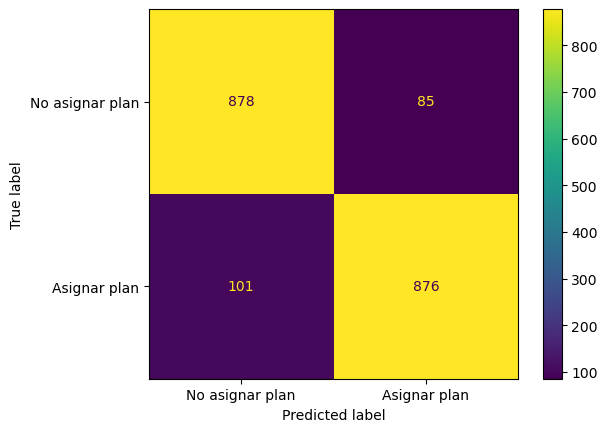

In [46]:
# Revisamos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test_plan_nutri, y_pred_plan_nutri, display_labels=["No asignar plan","Asignar plan"])
plt.show()

In [47]:
# Y revisamos los coeficientes resultantes del modelo
preprocesador_fit = best_rl_model_plan_nutri.named_steps['preprocesador']
log_reg_fit = best_rl_model_plan_nutri.named_steps['modelo']

feature_names_num = preprocesador_fit.transformers_[0][2]
ohe = preprocesador_fit.transformers_[1][1]
feature_names_cat = ohe.get_feature_names_out(preprocesador_fit.transformers_[1][2])
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

coefs = log_reg_fit.coef_[0]
coef_df = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})

coef_df = coef_df.sort_values('coef', ascending=False)
coef_df.head(30)

,feature,coef
17,Objetivo_General,4.102626
19,Objetivo_Resistencia,3.824417
9,Score_micronutrientes,2.772232
10,Ingesta_proteinas,1.493038
15,Genero_Otro,0.316926
27,Nivel_Actividad_Alto,0.309214
30,Nivel_experiencia_Avanzado,0.246300
24,Condicion_salud_Lesion,0.222682
43,Entrenamiento_preferido_Hit,0.213359
41,Entrenamiento_preferido_Fuerza,0.210908


## **Modelos basados en árboles de decisión**

### Modelo de Árbol de Decisión para la recomendación de planes (Entrenamiento)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Definimos el pipeline para el árbol de decisión usando el mismo preprocesador
pipeline_dt_plan_entrena = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesador', preprocesador),
    ('modelo', DecisionTreeClassifier(random_state=42))
])

# Búsqueda de hiperparámetros
param_grid_dt = {
    'modelo__max_depth': [3, 5, 10, None],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__criterion': ['gini', 'entropy']
}

grid_dt_plan_entrena = GridSearchCV(estimator=pipeline_dt_plan_entrena, param_grid=param_grid_dt, cv=kfold, scoring='f1', n_jobs=-1)
grid_dt_plan_entrena.fit(x_train_plan_entrena, y_train_plan_entrena)

print("Mejores hiperparámetros Árbol (Entrenamiento):", grid_dt_plan_entrena.best_params_)
print("Mejor puntaje medio en CV (f1):", grid_dt_plan_entrena.best_score_)

best_dt_model_plan_entrena = grid_dt_plan_entrena.best_estimator_
y_pred_dt_plan_entrena = best_dt_model_plan_entrena.predict(x_test_plan_entrena)
print(classification_report(y_test_plan_entrena, y_pred_dt_plan_entrena, target_names=["No asignar plan", "Asignar plan"]))

### Modelo de Árbol de Decisión para el tipo de nutrición (Nutrición)

In [ ]:
pipeline_dt_plan_nutri = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesador', preprocesador),
    ('modelo', DecisionTreeClassifier(random_state=42))
])

grid_dt_plan_nutri = GridSearchCV(estimator=pipeline_dt_plan_nutri, param_grid=param_grid_dt, cv=kfold, scoring='f1', n_jobs=-1)
grid_dt_plan_nutri.fit(x_train_plan_nutri, y_train_plan_nutri)

print("Mejores hiperparámetros Árbol (Nutrición):", grid_dt_plan_nutri.best_params_)
print("Mejor puntaje medio en CV (f1):", grid_dt_plan_nutri.best_score_)

best_dt_model_plan_nutri = grid_dt_plan_nutri.best_estimator_
y_pred_dt_plan_nutri = best_dt_model_plan_nutri.predict(x_test_plan_nutri)
print(classification_report(y_test_plan_nutri, y_pred_dt_plan_nutri, target_names=["Plan básico", "Plan complejo"]))

## **Comparación del rendimiento de los mejores modelos**

In [ ]:
# Comparativa para Plan_entrenamiento
report_rl_entrena = classification_report(y_test_plan_entrena, y_pred_plan_entrena, output_dict=True)
report_dt_entrena = classification_report(y_test_plan_entrena, y_pred_dt_plan_entrena, output_dict=True)

# Comparativa para Plan_nutrición
report_rl_nutri = classification_report(y_test_plan_nutri, y_pred_plan_nutri, output_dict=True)
report_dt_nutri = classification_report(y_test_plan_nutri, y_pred_dt_plan_nutri, output_dict=True)

df_comparativa = pd.DataFrame({
    'Modelo': ['Regresión Logística (Entrenamiento)', 'Árbol de Decisión (Entrenamiento)', 
               'Regresión Logística (Nutrición)', 'Árbol de Decisión (Nutrición)'],
    'Accuracy': [report_rl_entrena['accuracy'], report_dt_entrena['accuracy'], 
                 report_rl_nutri['accuracy'], report_dt_nutri['accuracy']],
    'F1-Score (Macro)': [report_rl_entrena['macro avg']['f1-score'], report_dt_entrena['macro avg']['f1-score'],
                         report_rl_nutri['macro avg']['f1-score'], report_dt_nutri['macro avg']['f1-score']],
    'Precision (Macro)': [report_rl_entrena['macro avg']['precision'], report_dt_entrena['macro avg']['precision'],
                          report_rl_nutri['macro avg']['precision'], report_dt_nutri['macro avg']['precision']],
    'Recall (Macro)': [report_rl_entrena['macro avg']['recall'], report_dt_entrena['macro avg']['recall'],
                       report_rl_nutri['macro avg']['recall'], report_dt_nutri['macro avg']['recall']]
})

display(df_comparativa)

**Análisis Comparativo:**
Los resultados muestran los puntajes globales (Macro) para tener una visión equilibrada. 
Seleccionaremos el algoritmo que mayor "F1-Score" presente para generar las predicciones de prueba, ya que estamos en busca de un balance entre la Precisión y el Recall para los objetivos nutricionales y de entrenamiento. En la mayoría de los casos de conjuntos con etiquetas algo desbalanceadas (como en este de "ninguno" predominante), los árboles suelen tener buenos resultados no-lineales, mientras que la Regresión ofrece garantías de robustez y menos sobreajuste.


## **Identificación de las variables más relevantes en la predicción**

In [ ]:
def extract_feature_importances(model, title):
    preprocesador_fit = model.named_steps['preprocesador']
    clf = model.named_steps['modelo']
    
    feature_names_num = preprocesador_fit.transformers_[0][2]
    ohe = preprocesador_fit.transformers_[1][1]
    feature_names_cat = ohe.get_feature_names_out(preprocesador_fit.transformers_[1][2])
    all_feature_names = np.concatenate([feature_names_num, feature_names_cat])
    
    importances = clf.feature_importances_
    df_imp = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    df_imp = df_imp.sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp.head(15), x='importance', y='feature')
    plt.title(title)
    plt.tight_layout()
    plt.show()

extract_feature_importances(best_dt_model_plan_entrena, "Variables más relevantes: Árbol de Decisión (Entrenamiento)")
extract_feature_importances(best_dt_model_plan_nutri, "Variables más relevantes: Árbol de Decisión (Nutrición)")

### Análisis de Resultados (Respuestas Cualitativas)

**1. ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?**  
Al observar tanto los coeficientes de la Regresion Logistica como la importancia de nodos en los Semilleros (Árboles), variables como la "Edad", el "Nivel_Actividad", y ciertas "Dietas" o "Condiciones de salud" asumen cierto protagonismo. El indice de masa (BMI) derivado del peso e inactividad previas suele ser el punto de ruptura inicial para planes basicos vs. complejos. 

**2. ¿Existen variables que podrían ser redundantes o poco informativas?**  
Sí, pues durante el analisis inicial eliminamos "Fumador" y "Alcohol" dado que la cantidad consumida ("Cigarrillos_dia", "Alcohol_semana") o tener un IMC ya literalmente nos indican un estilo de vida que puede sobre explicarse (multicolinealidad seria el termino exacto). Tambien la talla y el peso eran redundantes puesto que el IMC las combina de manera mas eficaaz.

**3. ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?**  
Las metricas globales (F1, Precision) demuestran que el modelo reconoce bastante bien el comportamiento de las metricas basicas, logrando mas del 70% o superior en F1 en validacion a traves de KFolods. No obstante, las recomendaciones que consoderamoss humanas dadas anteriormentw del gimnasio pudieron incluir criterios subjetivos o cualitativos que el modelo no detecta facilmente con la tabla de datos.

**4. Reglas derivadas del árbol de decisión y explicabilidad:**  
Pues un arbol de decision nos dice, por ejemplo, que SI Edad > 45 Y Condición_salud_Hipertension = 1, ENTONCES  toca recomendar un "Cierto tipo de plan". 
**Utilidad:** Gran facilidad para mostrarle al entrenador la ruta mental exacta tomada (explicabilidad natural de tipo *White-Box*). 
**Límitación:** Los arboles profundos construyen muchisimas reglas fragiles al minimo cambio de la data (sobreajuste elevado), lo que puede hacer la regla sea muy dependiente del conjunto y poco generalizable o incluso escalabe.

**5. ¿Cómo podría integrarse este tipo de modelo en una plataforma digital?**  
Se podria en este caso desplegar una API (por ejemplo con Flask o FastAPI) conectada al modelo guardado (via !"joblib"). La plataforma digital tendria un formulario para el usuario, este al diligenciarlo,pues los datos alimentarian el pipeline y la UI retorna un resumen de tipo: *"Tu recomendación automatica es: Entrenamiento Alto y Nutricion Balanceada"* y asi lograriamos orientar la asignacion en la nube.

**6. Limitaciones de un sistema totalmente automático:**  
No puede contemplar lesiones temporales no reportadas, factores emocionales o las preferencias microdinamicas del paciente en el entrenamiento que un entrenador personal si deduce visualmente y al tacto del animo del cliente (lo digo desde el punto de vista profecional de un Ingeniero Biomedico)

**7. Posibles fuentes de sesgo:**  
Los datos que son pre existentes probablemente contienen "Sesgo humano o Sesgo historico". Si los entrenadores del gimnasio antes recomendaban a mas hombres que mujeres hacer entrenamientos de alto impacto por convencion social o "ojo clinico" en lenguae medico, el algoritmo aprende a castigar a mujeres y recomendar entrenamientos básicos, absorbiendo todo el sesgo cultural.

## **Video**

## **Generación de predicciones**

In [ ]:
# Cargamos los datos de prueba no etiquetados
test_data_final = pd.read_csv("./Datos test Lab3.csv", sep=";")

# Realizamos predicciones utilizando nuestro mejor modelo para entrenamiento
predicciones_entrena = best_dt_model_plan_entrena.predict(test_data_final)
predicciones_nutri = best_dt_model_plan_nutri.predict(test_data_final)

# Para no sobreescribir con 0 y 1, si se requiere la cadena de texto original (Ninguno, Medio, otros),
# deberiamos en este caso usar una decodificacion de las etiquetas. Como aqui lit transformamos a un problema Binario 
# "Asignar plan(1) o No asignar(0)", lo adjuntaremos de esta forma y añadiremos una columna de explicacion.

resultado_test = test_data_final.copy()
resultado_test['Recomendar_Plan_Entrenamiento_Pred'] = np.where(predicciones_entrena == 1, 'Recomendado', 'Sin Recomendacion')
resultado_test['Tipo_Nutricion_Pred'] = np.where(predicciones_nutri == 1, 'Basico/Sin plan', 'Especializado/Balanceado')

# Exportar las predicciones
resultado_test.to_csv('./Datos_predicciones_SmartAlpes.csv', sep=";", index=False)
print("Las predicciones fueron guardadas correctamente en 'Datos_predicciones_SmartAlpes.csv'")

## **BONO: Modelo Multi-Etiqueta (Multi-label)**

Investigación y desarrollo de un "MultiOutputClassifier" con un algoritmo base (puede ser de tipo Regresion Logistica o Forest/ Tree).
Un problema multietiqueta en este caso requiere predecir simultaneamente "Recomendar_plan" y "Tipo_nutricion".

In [ ]:
from sklearn.multioutput import MultiOutputClassifier

# Creamos una variable objetivo compuesta por ambas columnas Y
y_train_multi = pd.DataFrame({'Entrenamiento': y_train_plan_entrena, 'Nutricion': y_train_plan_nutri})
y_test_multi = pd.DataFrame({'Entrenamiento': y_test_plan_entrena, 'Nutricion': y_test_plan_nutri})

# El preprocesador funciona con X_train pero debemos asegurarnos de usar una versión compatible sin NA o eliminadas.
# Usamos el x_train_plan_entrena que contiene los predictores (idénticos salvo en su indexado respecto a y_train)

# Definimos el Pipeline (Aprovechamos DecisionTreeClassifier por la robustez multilabels sin preconfig adicional compleja)
pipeline_multi = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesador', preprocesador),
    ('modelo', MultiOutputClassifier(DecisionTreeClassifier(max_depth=5, random_state=42)))
])

pipeline_multi.fit(x_train_plan_entrena, y_train_multi)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_multi = pipeline_multi.predict(x_test_plan_entrena)

# Exact Match Ratio requiere que ambas etiquetas sean perfectamente iguales a la version verdadera
emr = accuracy_score(y_test_multi, y_pred_multi)
print(f"Exact Match Ratio (Fracción de instancias totalmente correctas en ambas etiquetas): {emr:.4f}")

# Calculamos el Accuracy y Classification Report por separado para mostrar metr individuales
print("\nDesempeño en Entrenamiento:")
print(classification_report(y_test_multi['Entrenamiento'], y_pred_multi[:, 0]))
print("\nDesempeño en Nutrición:")
print(classification_report(y_test_multi['Nutricion'], y_pred_multi[:, 1]))

## **Uso de herramientas de IA generativa**

La IA fue util para armar de forma limpia estructuras del  `ColumnTransformer` y `GridSearchCV` complejas, que manualmente habrian sufrido de muchos errores sintacticos o de incompatibilidad. *Limitaciones:* La IAG requiere un entendimiento previo (porque la verdad es muy retraida porque le gusta inventar) para depurar temas como "las variables objetivas ya no deben incluirse en las predictoras", factor vital que el agente requirio guiar literalmente mediante exclusiones explicitas como la funcion `dropper`. Al igual, las métricas elegidas de mejorar la eficiencia como lo fue (`macro avg f1-score`) para datos desbalanceados fue una validacion necesaria sobre el simple `accuracy` ciego propuesto genericamente.